In [ ]:
# These come pre-installed in Colab, just import them
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Should print: Using device: cuda

Using device: cuda


In [ ]:
# Define transformations
# Normalize: converts pixel values (0-255) to (-1 to 1)
# This helps the model learn faster
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download CIFAR-10 dataset (will download automatically ~170MB)
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,       # Training data (50,000 images)
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,      # Test data (10,000 images)
    download=True,
    transform=transform
)

# DataLoader: feeds images to the model in batches
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,    # Process 64 images at a time
    shuffle=True      # Shuffle so model doesn't memorize order
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Class names
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [56:05<00:00, 50.7kB/s]


Training samples: 50000
Test samples: 10000


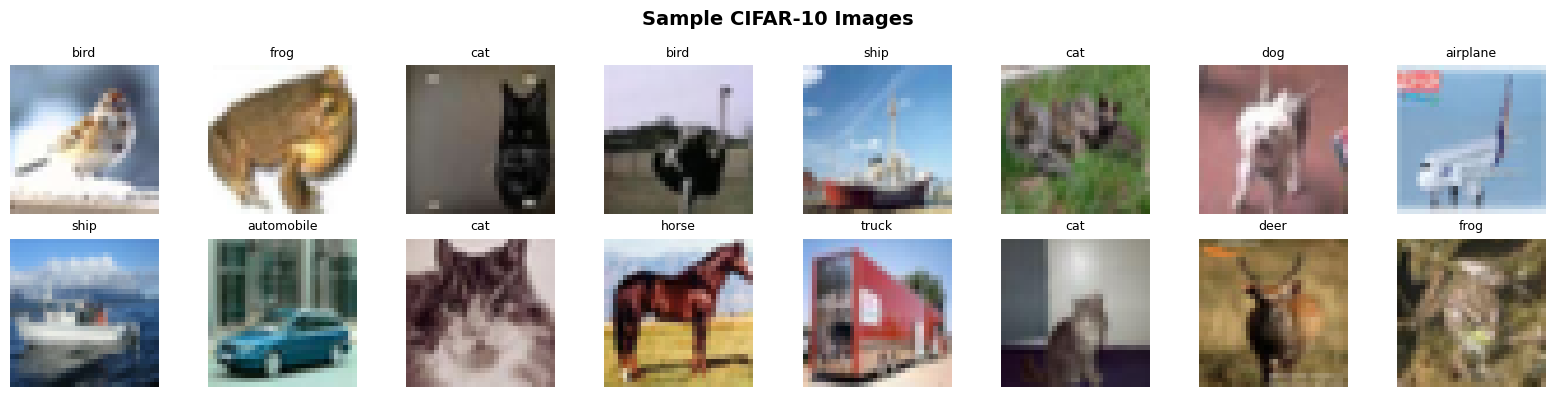

In [ ]:
# See what the data looks like
def show_images(loader, classes):
    images, labels = next(iter(loader))

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    axes = axes.flatten()

    for i in range(16):
        img = images[i]
        # Unnormalize: reverse the normalization we did earlier
        img = img * 0.5 + 0.5
        img = img.permute(1, 2, 0).numpy()  # Convert to HxWxC format

        axes[i].imshow(img)
        axes[i].set_title(classes[labels[i]], fontsize=9)
        axes[i].axis('off')

    plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_images(train_loader, classes)
# Save this screenshot for your LinkedIn post!

In [ ]:
# This is the most important part — the actual neural network
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # BLOCK 1: First set of Conv layers
        # Input: 3 channels (RGB), Output: 32 feature maps
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv layer
            nn.BatchNorm2d(32),                           # Normalize
            nn.ReLU(),                                    # Activation
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # Shrink: 32x32 → 16x16
            nn.Dropout(0.25)                              # Prevent overfitting
        )

        # BLOCK 2: Deeper features
        # Input: 32 channels, Output: 64 feature maps
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # Shrink: 16x16 → 8x8
            nn.Dropout(0.25)
        )

        # BLOCK 3: Even deeper features
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # Shrink: 8x8 → 4x4
            nn.Dropout(0.25)
        )

        # CLASSIFIER: Flatten and make final decision
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # 128 x 4 x 4 = 2048 numbers
            nn.Linear(128 * 4 * 4, 512),    # Fully connected layer
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)              # 10 outputs = 10 classes
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Create model and move it to GPU
model = CNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout

In [ ]:
# Loss function: measures how wrong the model is
criterion = nn.CrossEntropyLoss()

# Optimizer: adjusts weights to reduce loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler: reduce LR when model stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)
print("Training setup complete!")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001)")

Training setup complete!
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


In [ ]:
# Lists to track progress for graphs later
train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []

EPOCHS = 30  # Train for 30 rounds through the data

for epoch in range(EPOCHS):
    # ── TRAINING PHASE ──────────────────────────
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # Clear old gradients
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()                # Backward pass
        optimizer.step()               # Update weights

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    # ── EVALUATION PHASE ────────────────────────
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():   # Don't calculate gradients during testing
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc  = 100. * correct / total

    # Save for graphs
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    scheduler.step(test_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.1f}% | "
          f"Test Loss: {test_loss:.3f}  | Test Acc: {test_acc:.1f}%")

print("\n✅ Training complete!")

Epoch [01/30] Train Loss: 1.472 | Train Acc: 46.0% | Test Loss: 1.126  | Test Acc: 59.0%
Epoch [02/30] Train Loss: 1.069 | Train Acc: 62.1% | Test Loss: 0.902  | Test Acc: 68.0%
Epoch [03/30] Train Loss: 0.903 | Train Acc: 68.6% | Test Loss: 0.821  | Test Acc: 71.5%
Epoch [04/30] Train Loss: 0.804 | Train Acc: 72.0% | Test Loss: 0.735  | Test Acc: 74.2%
Epoch [05/30] Train Loss: 0.733 | Train Acc: 74.8% | Test Loss: 0.669  | Test Acc: 76.6%
Epoch [06/30] Train Loss: 0.676 | Train Acc: 76.9% | Test Loss: 0.641  | Test Acc: 78.1%
Epoch [07/30] Train Loss: 0.639 | Train Acc: 78.1% | Test Loss: 0.583  | Test Acc: 80.2%
Epoch [08/30] Train Loss: 0.588 | Train Acc: 80.0% | Test Loss: 0.563  | Test Acc: 80.8%
Epoch [09/30] Train Loss: 0.555 | Train Acc: 81.1% | Test Loss: 0.491  | Test Acc: 83.5%
Epoch [10/30] Train Loss: 0.533 | Train Acc: 81.8% | Test Loss: 0.510  | Test Acc: 82.8%
Epoch [11/30] Train Loss: 0.497 | Train Acc: 83.2% | Test Loss: 0.495  | Test Acc: 83.0%
Epoch [12/30] Train L

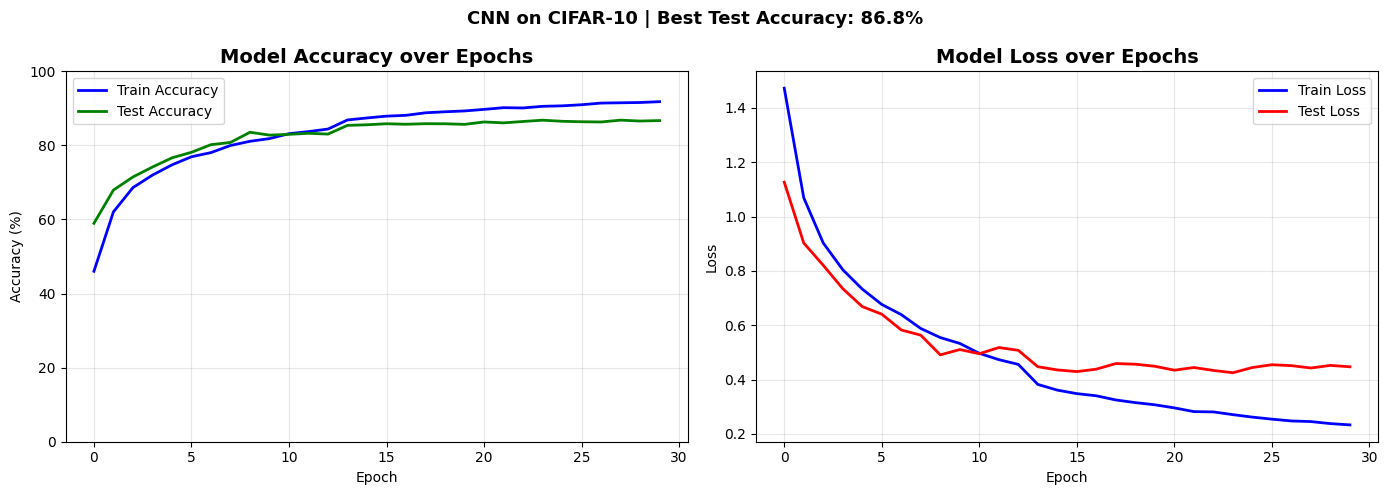


🏆 Best Test Accuracy: 86.82%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy graph
ax1.plot(train_accs, label='Train Accuracy', color='blue',  linewidth=2)
ax1.plot(test_accs,  label='Test Accuracy',  color='green', linewidth=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 100])

# Loss graph
ax2.plot(train_losses, label='Train Loss', color='blue',  linewidth=2)
ax2.plot(test_losses,  label='Test Loss',  color='red',   linewidth=2)
ax2.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'CNN on CIFAR-10 | Best Test Accuracy: {max(test_accs):.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🏆 Best Test Accuracy: {max(test_accs):.2f}%")

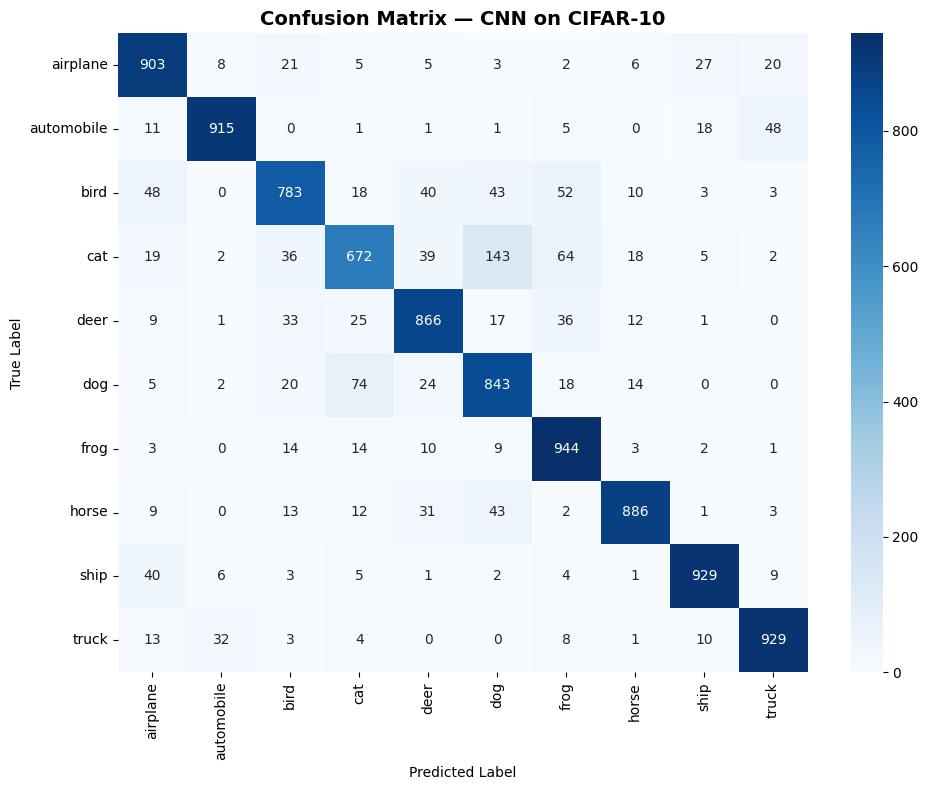

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — CNN on CIFAR-10', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save trained model weights
torch.save(model.state_dict(), 'cnn_cifar10.pth')
print("✅ Model saved as cnn_cifar10.pth")

# Download it to your computer
from google.colab import files
files.download('cnn_cifar10.pth')
files.download('training_results.png')
files.download('confusion_matrix.png')
files.download('sample_images.png')

✅ Model saved as cnn_cifar10.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>